In [2]:
import pandas as pd
import numpy as np

# Création du dataset
data = {
    "id_transaction": range(1, 21),
    "date_vente": pd.date_range(start="2024-01-05", periods=20, freq="15D"),
    "ville": [
        "Marrakech", "Casablanca", "Rabat", "Marrakech", "Tanger",
        "Casablanca", "Rabat", "Marrakech", "Agadir", "Fes",
        "Marrakech", "Casablanca", "Rabat", "Tanger", "Agadir",
        "Fes", "Marrakech", "Casablanca", "Rabat", "Agadir"
    ],
    "type_bien": [
        "Appartement", "Villa", "Appartement", "Maison", "Appartement",
        "Villa", "Maison", "Appartement", "Villa", "Maison",
        "Appartement", "Villa", "Maison", "Appartement", "Villa",
        "Maison", "Appartement", "Villa", "Maison", "Appartement"
    ],
    "surface_m2": [
        80, 200, 75, 120, 65, 220, 110, 85, 250, 130,
        90, 210, 115, 70, 240, 140, 95, 230, 105, 88
    ],
    "prix_vente": [
        800000, 3200000, 750000, 1200000, 680000,
        3500000, 1100000, 820000, 4000000, 1300000,
        900000, 3300000, 1150000, 700000, 4200000,
        1350000, 950000, 3400000, 1080000, 870000
    ],
    "nombre_pieces": [
        3, 6, 3, 4, 2, 7, 5, 3, 8, 5,
        3, 6, 5, 2, 7, 5, 4, 6, 5, 3
    ]
}

df = pd.DataFrame(data)

In [3]:
df["prix_m2"] = df["prix_vente"] / df["surface_m2"]

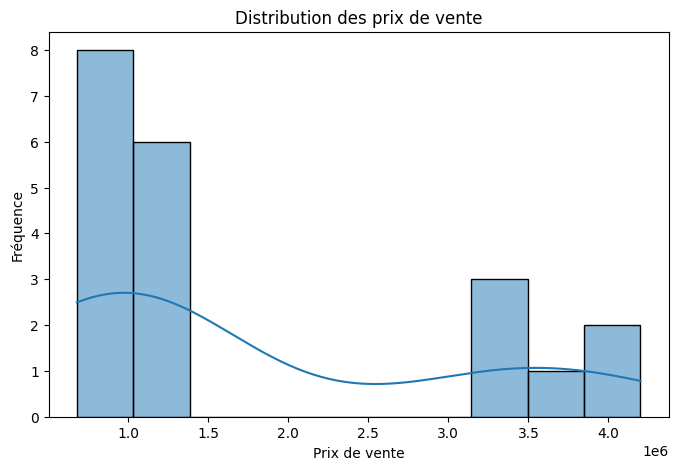

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df["prix_vente"], bins=10, kde=True)

plt.title("Distribution des prix de vente")
plt.xlabel("Prix de vente")
plt.ylabel("Fréquence")

plt.show()

In [5]:
print(df["prix_vente"].skew())

0.9713332372520139


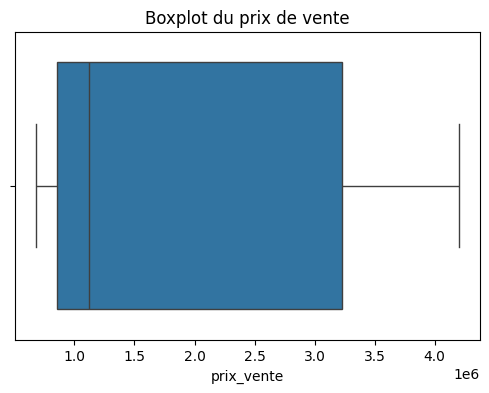

In [6]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["prix_vente"])
plt.title("Boxplot du prix de vente")
plt.show()

In [7]:
Q1 = df["prix_vente"].quantile(0.25)
Q3 = df["prix_vente"].quantile(0.75)
IQR = Q3 - Q1

borne_inf = Q1 - 1.5 * IQR
borne_sup = Q3 + 1.5 * IQR

outliers = df[(df["prix_vente"] < borne_inf) | (df["prix_vente"] > borne_sup)]

print("Nombre d'outliers :", len(outliers))

Nombre d'outliers : 0


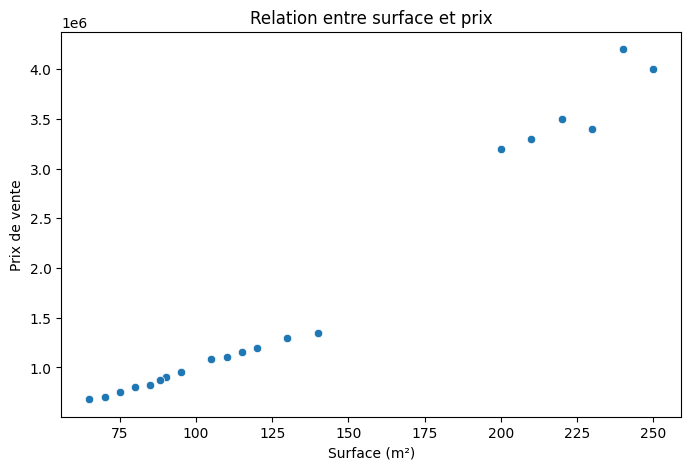

In [8]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="surface_m2", y="prix_vente", data=df)
plt.title("Relation entre surface et prix")
plt.xlabel("Surface (m²)")
plt.ylabel("Prix de vente")
plt.show()

In [9]:
corr_matrix = df.corr(numeric_only=True)
print(corr_matrix)

                id_transaction  surface_m2  prix_vente  nombre_pieces  \
id_transaction        1.000000    0.087700    0.041531       0.108052   
surface_m2            0.087700    1.000000    0.984255       0.930532   
prix_vente            0.041531    0.984255    1.000000       0.886321   
nombre_pieces         0.108052    0.930532    0.886321       1.000000   
prix_m2              -0.033231    0.928606    0.977334       0.801234   

                 prix_m2  
id_transaction -0.033231  
surface_m2      0.928606  
prix_vente      0.977334  
nombre_pieces   0.801234  
prix_m2         1.000000  


In [10]:
corr_prix = corr_matrix["prix_vente"].sort_values(ascending=False)
print(corr_prix)

prix_vente        1.000000
surface_m2        0.984255
prix_m2           0.977334
nombre_pieces     0.886321
id_transaction    0.041531
Name: prix_vente, dtype: float64


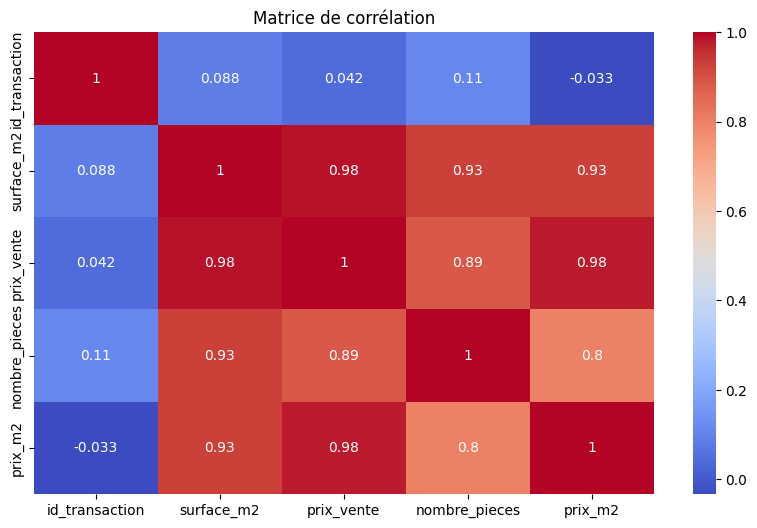

In [18]:
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matrice de corrélation")
plt.show()

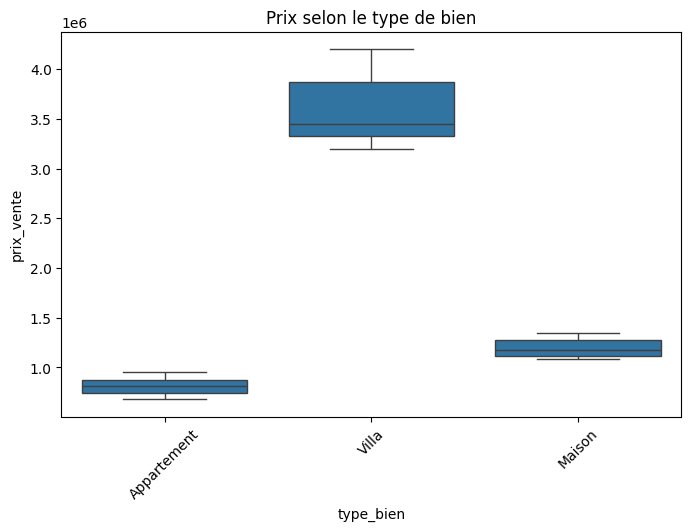

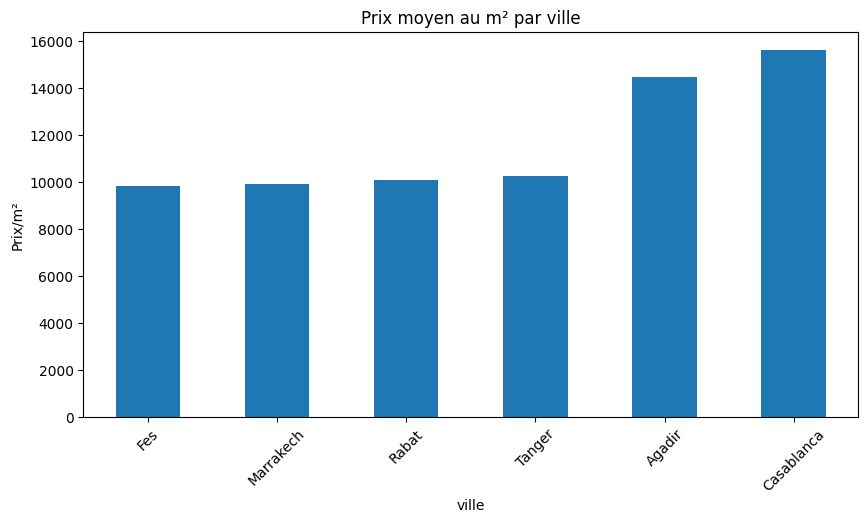

In [13]:
df["prix_m2"] = df["prix_vente"] / df["surface_m2"]

prix_ville = df.groupby("ville")["prix_m2"].mean().sort_values()

plt.figure(figsize=(10,5))
prix_ville.plot(kind="bar")
plt.title("Prix moyen au m² par ville")
plt.ylabel("Prix/m²")
plt.xticks(rotation=45)
plt.show()

In [14]:
Q1 = df["prix_vente"].quantile(0.25)
Q3 = df["prix_vente"].quantile(0.75)
IQR = Q3 - Q1

borne_inf = Q1 - 1.5 * IQR
borne_sup = Q3 + 1.5 * IQR

outliers = df[(df["prix_vente"] < borne_inf) | (df["prix_vente"] > borne_sup)]

print("Nombre d'outliers :", len(outliers))

Nombre d'outliers : 0


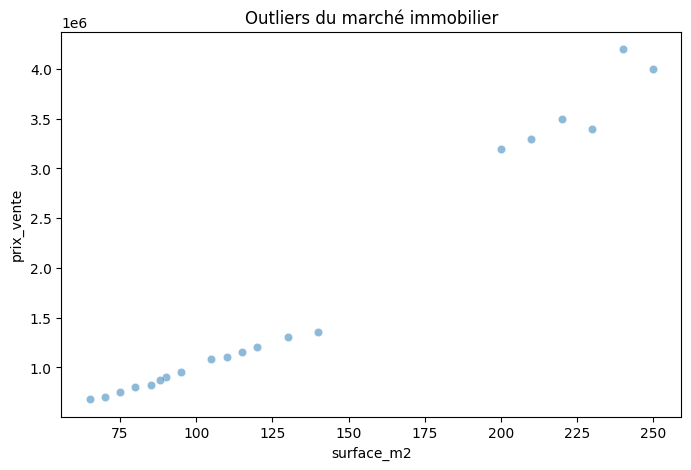

In [15]:
plt.figure(figsize=(8,5))

# données normales
sns.scatterplot(x="surface_m2", y="prix_vente", data=df, alpha=0.5)

# outliers
sns.scatterplot(x="surface_m2", y="prix_vente", data=outliers, color="red")

plt.title("Outliers du marché immobilier")
plt.show()

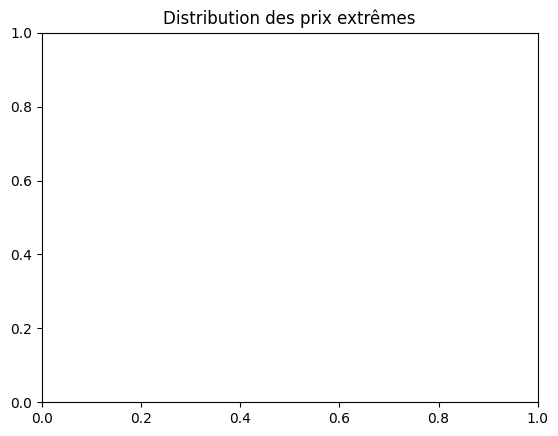

In [17]:
sns.histplot(outliers["prix_vente"], bins=20, color="red")
plt.title("Distribution des prix extrêmes")
plt.show()